In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler , LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error,accuracy_score, classification_report, confusion_matrix

In [2]:
df=pd.read_csv("Global_Pollution_Analysis - Global_Pollution_Analysis.csv")
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
a=df["Country"].unique()
print(len(a))

175


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [5]:
df

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Latvia,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,Bangladesh,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,Korea,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,Vanuatu,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [6]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [7]:
country_freq = df["Country"].value_counts()
df["Country"] = df["Country"].map(country_freq)
df.drop(columns=["Country"], inplace=True)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Year                                    200 non-null    int64  
 1   Air_Pollution_Index                     200 non-null    float64
 2   Water_Pollution_Index                   200 non-null    float64
 3   Soil_Pollution_Index                    200 non-null    float64
 4   Industrial_Waste (in tons)              200 non-null    float64
 5   Energy_Recovered (in GWh)               200 non-null    float64
 6   CO2_Emissions (in MT)                   200 non-null    float64
 7   Renewable_Energy (%)                    200 non-null    float64
 8   Plastic_Waste_Produced (in tons)        200 non-null    float64
 9   Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 10  Population (in millions)                200 non-null    float6

In [9]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


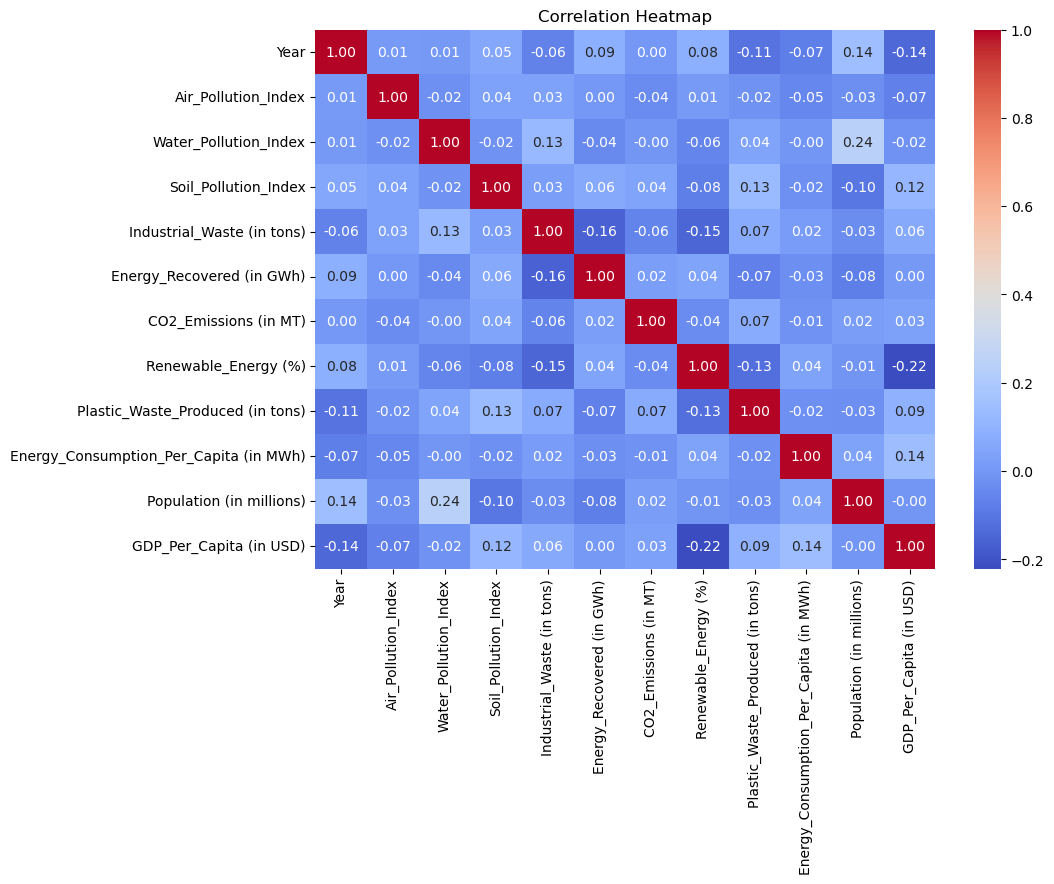

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
df["Year"]= df["Year"].astype(int)


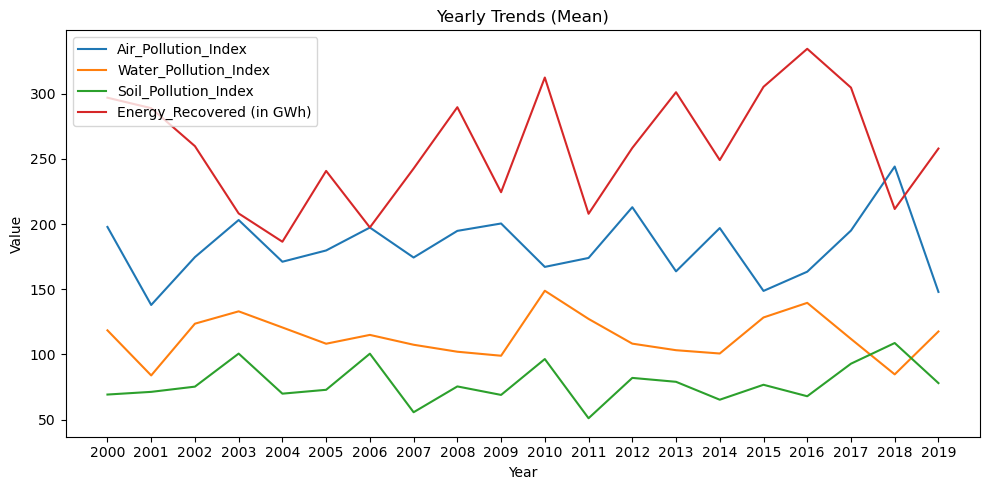

In [12]:
year=df.groupby("Year")[["Air_Pollution_Index",
                             "Water_Pollution_Index",
                             "Soil_Pollution_Index",
                             "Energy_Recovered (in GWh)"]].mean()
year.plot(figsize=(10,5))
plt.xticks(year.index)  
plt.title("Yearly Trends (Mean)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


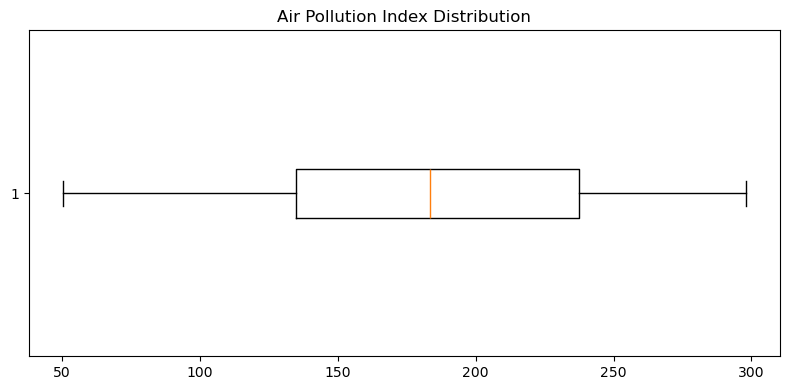

In [13]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Air_Pollution_Index"], vert=False)
plt.title("Air Pollution Index Distribution")
plt.tight_layout()
plt.show()


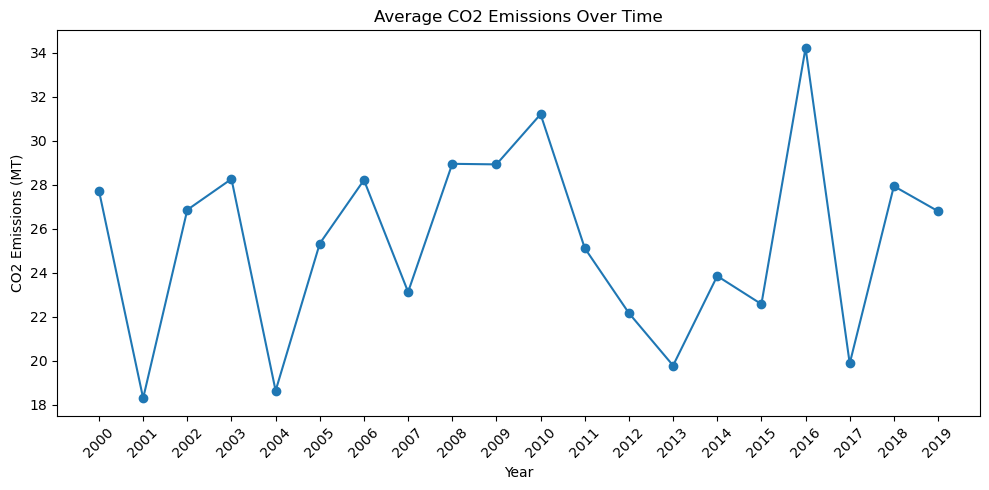

In [14]:
co2_yearly = df.groupby("Year")["CO2_Emissions (in MT)"].mean()
plt.figure(figsize=(10,5))
plt.plot(co2_yearly.index, co2_yearly.values, marker="o")
plt.title("Average CO2 Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (MT)")
plt.xticks(co2_yearly.index, rotation=45)
plt.tight_layout()
plt.show()


In [15]:
df["Energy_Consumption_Per_Capita (in MWh)"]

0      12.56
1       5.23
2      13.15
3       0.78
4      12.84
       ...  
195     6.28
196    15.18
197    14.11
198    12.44
199    11.72
Name: Energy_Consumption_Per_Capita (in MWh), Length: 200, dtype: float64

In [16]:
df.corr()["Energy_Recovered (in GWh)"].sort_values(ascending=False)

Energy_Recovered (in GWh)                 1.000000
Year                                      0.088332
Soil_Pollution_Index                      0.064076
Renewable_Energy (%)                      0.043533
CO2_Emissions (in MT)                     0.024758
GDP_Per_Capita (in USD)                   0.004535
Air_Pollution_Index                       0.002997
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Water_Pollution_Index                    -0.041828
Plastic_Waste_Produced (in tons)         -0.072946
Population (in millions)                 -0.075100
Industrial_Waste (in tons)               -0.161309
Name: Energy_Recovered (in GWh), dtype: float64

In [17]:
y=df["Energy_Recovered (in GWh)"]
'''x=df.drop(columns=["Energy_Recovered (in GWh)"])'''
x = df[[
    "Industrial_Waste (in tons)",
    "Plastic_Waste_Produced (in tons)",
    "Population (in millions)",
    "Year",
    "Soil_Pollution_Index"
]]


In [18]:
sc=StandardScaler()
x=sc.fit_transform(x)

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [20]:
model=LinearRegression()
model.fit(x_train,y_train)
pred=model.predict(x_test)

In [37]:
print("Linear Regression Results")
print("R2 :",r2_score(y_test,pred) )
print("MSE:",mean_squared_error(y_test,pred))
print("MAE:",mean_absolute_error(y_test,pred))

Linear Regression Results
R2 : -0.05035618186619906
MSE: 25399.961675210616
MAE: 140.0259467569479


In [21]:
r

-0.05035618186619906

25399.961675210616

140.0259467569479

In [26]:
df["Pollution_level"] = pd.cut(
    df["Air_Pollution_Index"],bins=3,labels=["Low", "Medium", "High"]
)


In [28]:
xc=df.drop(columns=["Pollution_level","Energy_Recovered (in GWh)"])
yc=df["Pollution_level"]


In [29]:
scaler_c = StandardScaler()
xc=scaler_c.fit_transform(xc)

In [30]:
xc_train,xc_test,yc_train,yc_test=train_test_split(xc,yc,test_size=0.2,random_state=42,stratify=yc)

In [33]:
logr = LogisticRegression(max_iter=2000, multi_class="multinomial")
logr.fit(xc_train, yc_train)
yc_pred = logr.predict(xc_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [34]:
print("Logistic Regression Results")
print("Accuracy:",accuracy_score(yc_test, yc_pred))
print("\nClassification Report:\n",classification_report(yc_test,yc_pred))
print("\nConfusion Matrix:\n",confusion_matrix(yc_test, yc_pred))


Logistic Regression Results
Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

        High       1.00      0.85      0.92        13
         Low       1.00      0.90      0.95        10
      Medium       0.85      1.00      0.92        17

    accuracy                           0.93        40
   macro avg       0.95      0.92      0.93        40
weighted avg       0.94      0.93      0.93        40


Confusion Matrix:
 [[11  0  2]
 [ 0  9  1]
 [ 0  0 17]]
